In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def restore_image_v1(image_path):
    degraded_image = cv2.imread(image_path)
    
    # Step 1: Mask Creation for Inpainting
    gray_image = cv2.cvtColor(degraded_image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray_image, 10, 255, cv2.THRESH_BINARY_INV)
    
    # Step 2: Inpainting to fill black patches
    inpainted_image = cv2.inpaint(degraded_image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    # Step 3: Denoising: Apply Gaussian smoothing
    denoised_image = cv2.GaussianBlur(inpainted_image, (5, 5), 0)

    # Plot and display the results
    fig, ax = plt.subplots(1, 3, figsize=(20, 10))
    ax[0].imshow(cv2.cvtColor(degraded_image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Degraded Image")
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Inpainting Mask")
    ax[2].imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
    ax[2].set_title("Restored and Denoised Image")
    plt.show()
    
    return denoised_image

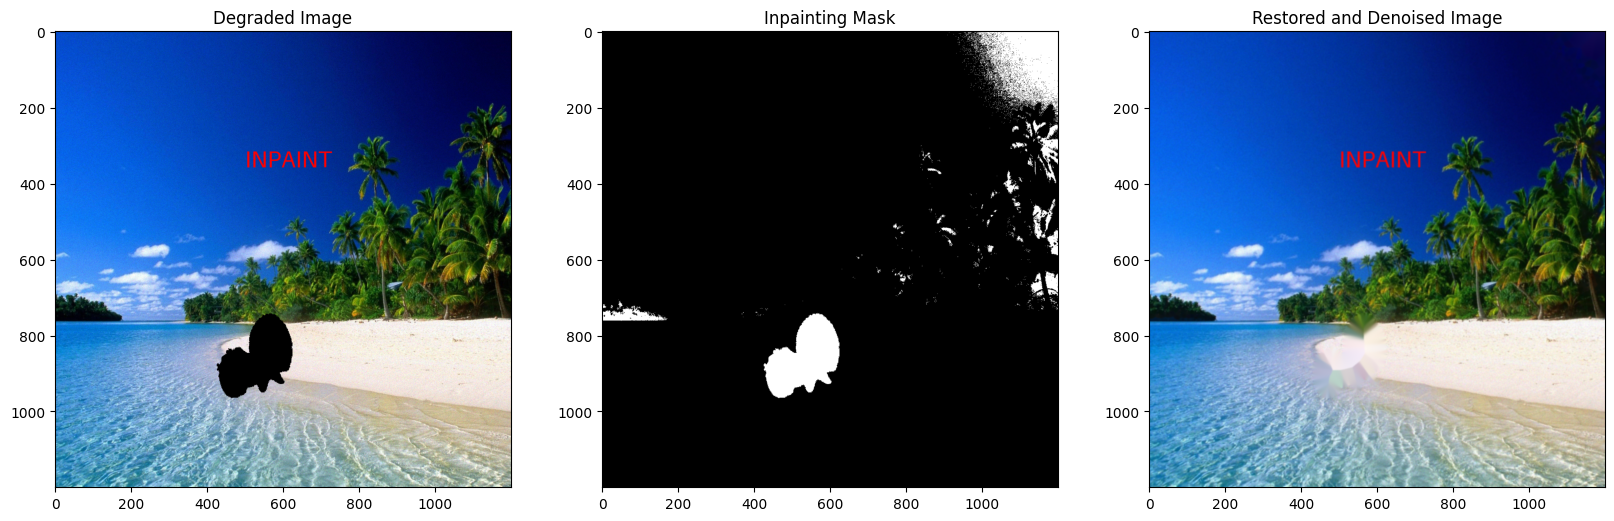

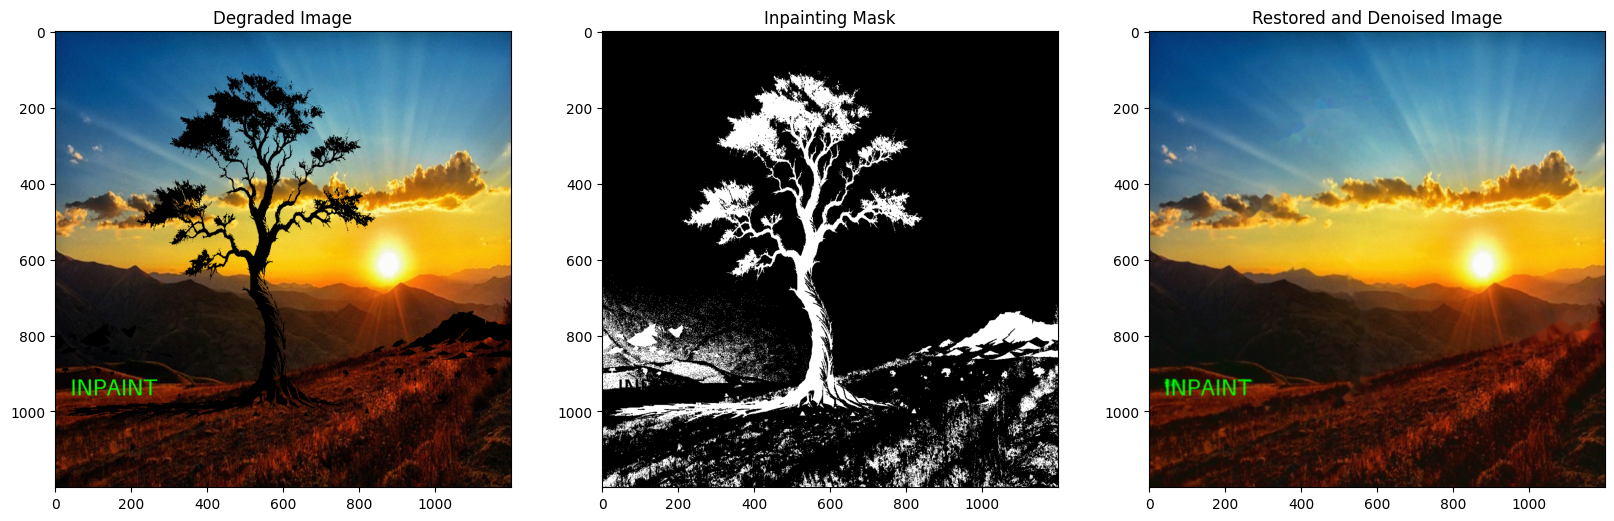

276.8386423611111
172.9913923611111
MSE: 224.9150173611111


In [7]:
# Restore the images
restored_image1 = restore_image_v1('Image1Degarded.png')
restored_image2 = restore_image_v1('Image2Degarded.png')

# Mean Squared Error function
def mean_square_error_image(image01, image02):
    error = np.sum((image01.astype("float") - image02.astype("float")) ** 2)
    error = error / float(1200 * 1200)
    print(error)
    return error

# MSE between the original and restored images
original_image1 = cv2.imread('Image1.png')
image1_error = mean_square_error_image(original_image1, restored_image1)
original_image2 = cv2.imread('Image2.png')
image2_error = mean_square_error_image(original_image2, restored_image2)
print(f'MSE: {(image1_error+image2_error)/2}')

In [8]:
def restore_image_v2(image_path):

    degraded_image = cv2.imread(image_path)

    # Step 1: Create a mask for black patches
    gray_image = cv2.cvtColor(degraded_image, cv2.COLOR_BGR2GRAY)
    _, black_patch_mask = cv2.threshold(gray_image, 10, 255, cv2.THRESH_BINARY_INV)

    # Step 2: Create a mask for the 'INPAINT' text that detects single-colored text using color threshold
    lower_bound = np.array([0, 0, 200])
    upper_bound = np.array([50, 50, 255])
    text_mask = cv2.inRange(degraded_image, lower_bound, upper_bound)

    # Combine both masks (black patch + text)
    combined_mask = cv2.bitwise_or(black_patch_mask, text_mask)

    # Step 3: Inpainting the image using the combined mask
    restored_image = cv2.inpaint(degraded_image, combined_mask, 3, cv2.INPAINT_TELEA)

    # Step 4: Denoising: Apply Gaussian smoothing
    denoised_image = cv2.GaussianBlur(restored_image, (5, 5), 0)

    # Plot and display the results
    fig, ax = plt.subplots(1, 3, figsize=(20, 10))
    ax[0].imshow(cv2.cvtColor(degraded_image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Degraded Image")
    ax[1].imshow(combined_mask, cmap='gray')
    ax[1].set_title("Inpainting Mask")
    ax[2].imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
    ax[2].set_title("Restored and Denoised Image")
    plt.show()

    return denoised_image

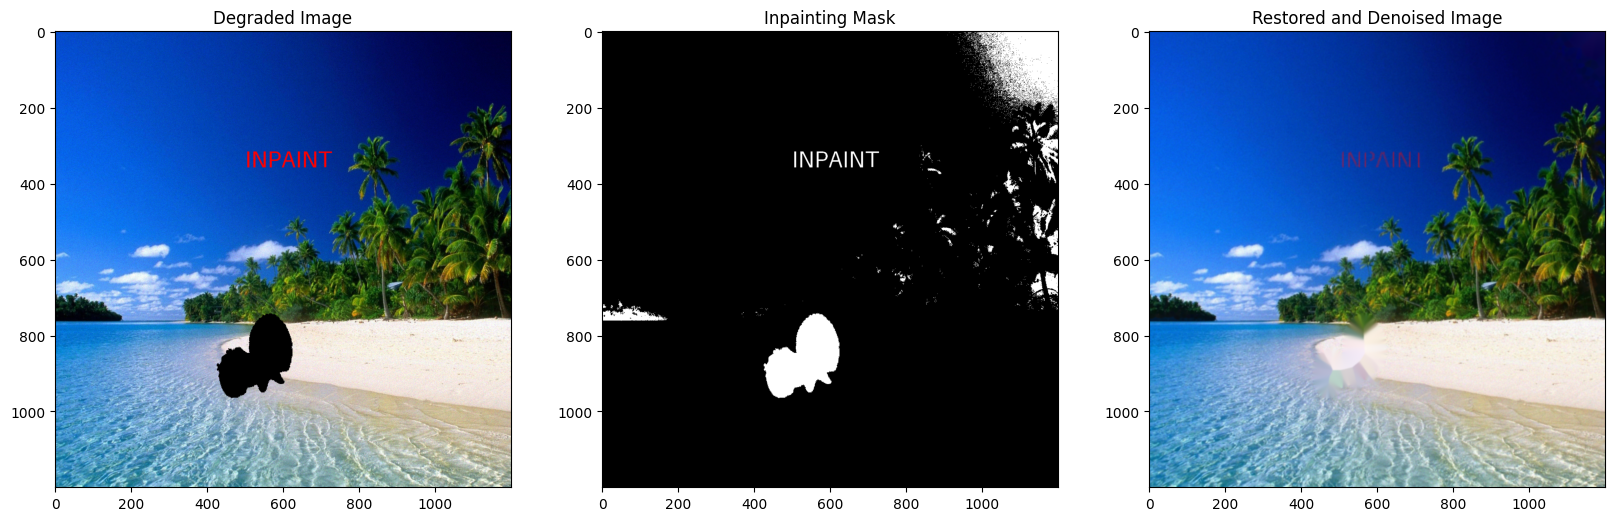

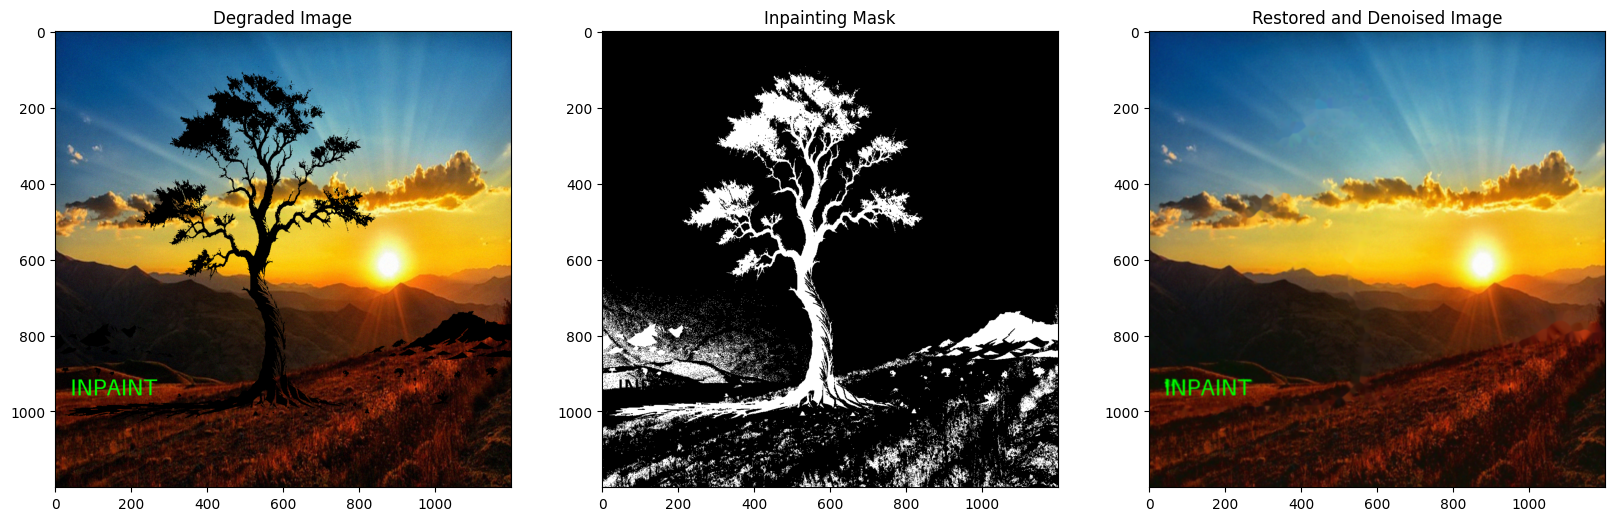

134.95176388888888
172.99204791666668
MSE: 153.9719059027778


In [9]:
# Restore the images
restored_image1 = restore_image_v2('Image1Degarded.png')
restored_image2 = restore_image_v2('Image2Degarded.png')

# Mean Squared Error function
def mean_square_error_image(image01, image02):
    error = np.sum((image01.astype("float") - image02.astype("float")) ** 2)
    error = error / float(1200 * 1200)
    print(error)
    return error

# MSE between the original and restored images
original_image1 = cv2.imread('Image1.png')
image1_error = mean_square_error_image(original_image1, restored_image1)
original_image2 = cv2.imread('Image2.png')
image2_error = mean_square_error_image(original_image2, restored_image2)
print(f'MSE: {(image1_error+image2_error)/2}')

In [10]:
def inpainting_algorithm(degraded_image):

    # Step 1: Adaptive Mask for "INPAINT" Text that accounts for both red and green text
    # Convert image to HSV to isolate colored text regions
    hsv_image = cv2.cvtColor(degraded_image, cv2.COLOR_BGR2HSV)

    # Define color ranges for red and green text in HSV
    image1 = cv2.imread('Image1Degarded.png')
    image2 = cv2.imread('Image2Degarded.png')

    # Convert images to HSV color space
    hsv_image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2HSV)
    hsv_image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2HSV)

    # Sample color for red text in Image1Degarded
    red_text_pixel = hsv_image1[318, 567]

    lower_red = np.array([red_text_pixel[0] - 5, 100, 100])
    upper_red = np.array([red_text_pixel[0] + 5, 255, 255])

    # Sample color for green text in Image2Degarded
    green_text_pixel = hsv_image2[920, 107]

    lower_green = np.array([green_text_pixel[0] - 5, 50, 50])
    upper_green = np.array([green_text_pixel[0] + 5, 255, 255])

    mask_red = cv2.inRange(hsv_image, lower_red, upper_red)

    mask_green = cv2.inRange(hsv_image, lower_green, upper_green)

    # Combine red and green text masks
    text_mask = cv2.bitwise_or(mask_red, mask_green)

    # Step 2: Create a Mask for black patches
    gray_image = cv2.cvtColor(degraded_image, cv2.COLOR_BGR2GRAY)
    _, black_patch_mask = cv2.threshold(gray_image, 10, 255, cv2.THRESH_BINARY_INV)

    # Step 3: Combine the black patch mask and refined text mask
    combined_mask = cv2.bitwise_or(black_patch_mask, text_mask)

    # Step 4: Inpainting using the combined mask
    restored_image = cv2.inpaint(degraded_image, combined_mask, 3, cv2.INPAINT_TELEA)

    return restored_image, combined_mask

def restore_image_v3(image_path):
    degraded_image = cv2.imread(image_path)
    restored_image, combined_mask = inpainting_algorithm(degraded_image)

    # Step 5: Denoising: Apply Gaussian smoothing
    denoised_image = cv2.GaussianBlur(restored_image, (5, 5), 0)
    
    # Plot and display the results
    fig, ax = plt.subplots(1, 3, figsize=(20, 10))
    ax[0].imshow(cv2.cvtColor(degraded_image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Degraded Image")
    ax[1].imshow(combined_mask, cmap='gray')
    ax[1].set_title("Inpainting Mask")
    ax[2].imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
    ax[2].set_title("Restored and Denoised Image")
    plt.show()

    return denoised_image


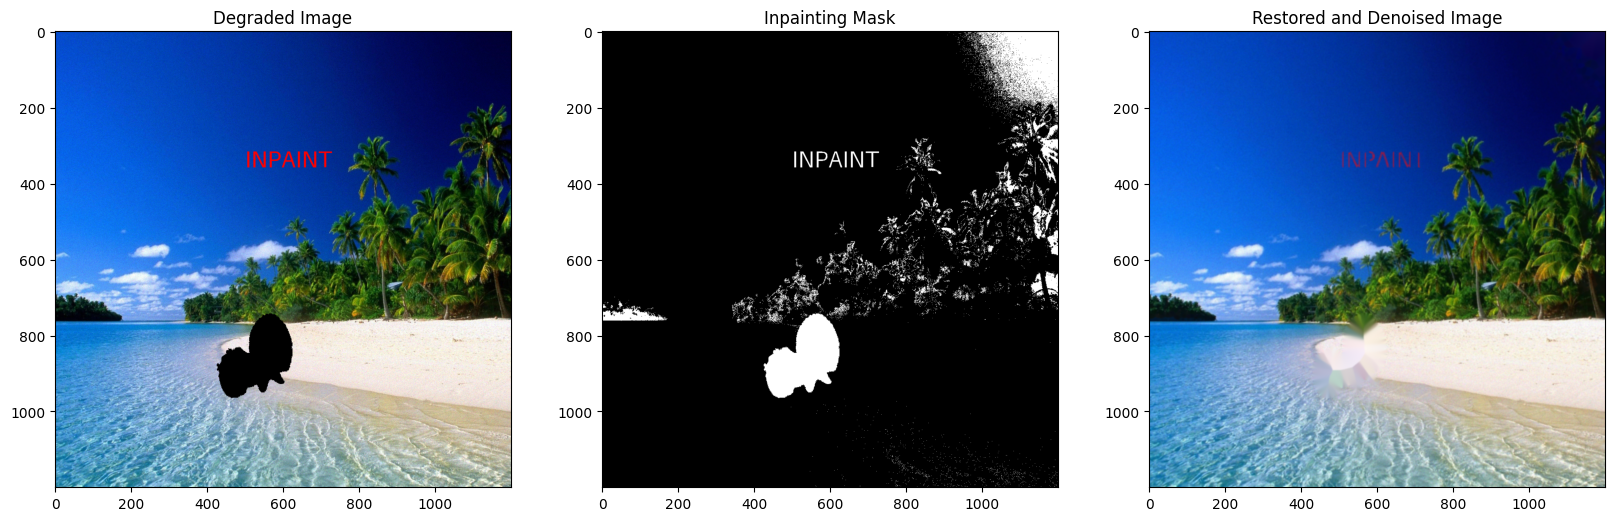

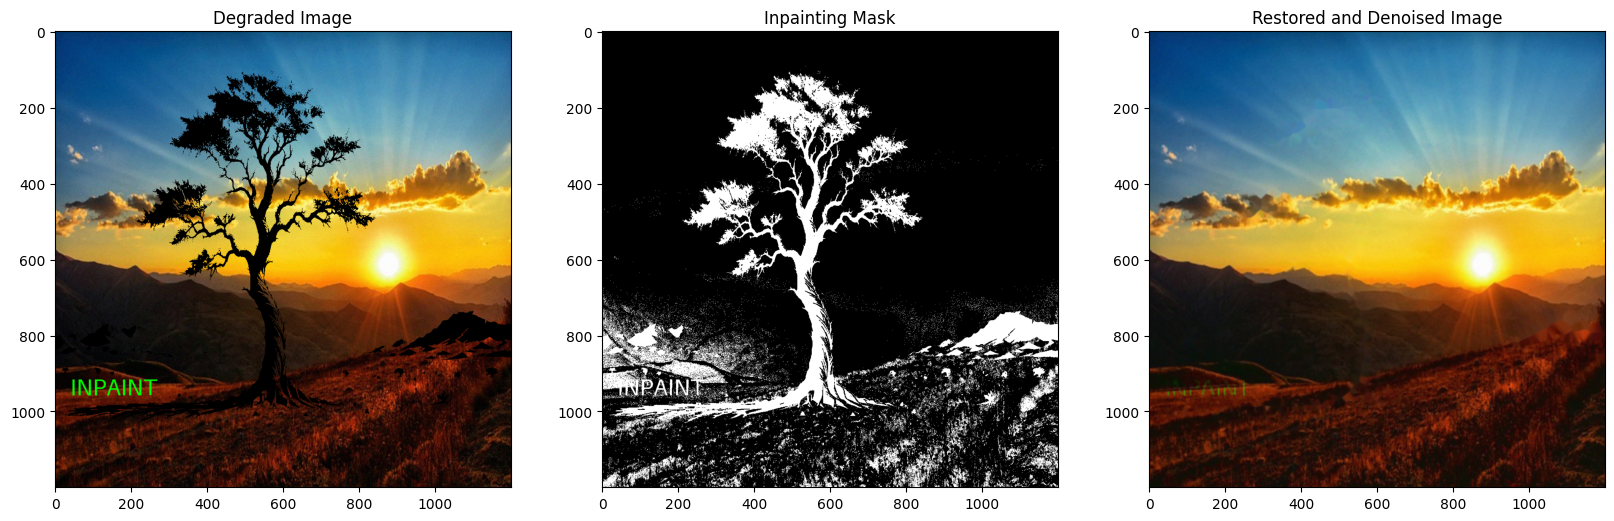

143.86242152777777
65.54448194444444
MSE: 104.7034517361111


In [11]:
# Restore the images
restored_image1 = restore_image_v3('Image1Degarded.png')
restored_image2 = restore_image_v3('Image2Degarded.png')

# Save the restored images
cv2.imwrite('Image1Restored.png', restored_image1)
cv2.imwrite('Image2Restored.png', restored_image2)

# Mean Squared Error function
def mean_square_error_image(image01, image02):
    error = np.sum((image01.astype("float") - image02.astype("float")) ** 2)
    error = error / float(1200 * 1200)
    print(error)
    return error

# MSE between the original and restored images
original_image1 = cv2.imread('Image1.png')
image1_error = mean_square_error_image(original_image1, restored_image1)
original_image2 = cv2.imread('Image2.png')
image2_error = mean_square_error_image(original_image2, restored_image2)
print(f'MSE: {(image1_error+image2_error)/2}')

# Prepare the submission data frame
submission = pd.DataFrame({
    "ID": list(range(1200*1200*3)),
    "Image1": restored_image1.flatten(),
    "Image2": restored_image2.flatten()
})

# Save submission to a CSV file
submission.to_csv('submission.csv', index=False)